In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prasadmalaiiiitk/pretrained/mobilenet_v3_small-047dcff4.pth
/kaggle/input/datasets/prasadmalaiiiitk/charlie-002/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_12_png.rf.566726d03bb59741293c5a5c58d71f5e_aug_2.jpg
/kaggle/input/datasets/prasadmalaiiiitk/charlie-002/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_45_png.rf.7b0c39c7948b368961c4bbc376c93d99.jpg
/kaggle/input/datasets/prasadmalaiiiitk/charlie-002/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_43_png.rf.225187fb6b8111d171ffcccb2e905e3a_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/charlie-002/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_50_png.rf.15b257af83325aa3721cf4463a3ce1b8_aug_1.jpg
/kaggle/input/datasets/prasadmalaiiiitk/charlie-002/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_47_png.rf.96ba9988494f51b9f661609792706976_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/charlie-002/sem-dataset

STEP 2: Imports & Global Config

In [2]:
from PIL import Image
import os
from collections import Counter

dataset_path = "/kaggle/input/datasets/prasadmalaiiiitk/charlie-002"

sizes = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)   # (width, height)
            except:
                print("Error reading:", img_path)

size_count = Counter(sizes)

print("Unique image sizes found:")
for size, count in size_count.items():
    print(size, ":", count)

Unique image sizes found:
(224, 224) : 2667
(512, 512) : 262
(480, 480) : 8
(512, 511) : 3
(640, 640) : 21


In [3]:
!pip install torch torchvision scikit-learn

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha      # class weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class

        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import copy
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# Data Transforms
# -----------------------

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05),
        scale=(0.9,1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -----------------------
# Load Dataset
# -----------------------

train_dataset = datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/charli001/sem-dataset/stage2/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/charli001/sem-dataset/stage2/valid", transform=val_transforms)
test_dataset  = datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/charli001/sem-dataset/stage2/test", transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

num_classes = 5

# -----------------------
# Compute Class Weights
# -----------------------

class_counts = np.bincount(train_dataset.targets)
total_samples = sum(class_counts)

class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
#criterion = FocalLoss(alpha=class_weights, gamma=2.0)
# -----------------------
# Load Pretrained Model
# -----------------------

model = models.mobilenet_v3_small(weights=None)
state_dict = torch.load("/kaggle/input/datasets/prasadmalaiiiitk/pretrained/mobilenet_v3_small-047dcff4.pth", map_location=device)

model.load_state_dict(state_dict)

# Replace classifier
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

model = model.to(device)

# Freeze backbone initially
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

# -----------------------
# Early Stopping Setup
# -----------------------

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0
patience = 7
trigger_times = 0

# -----------------------
# Training Loop
# -----------------------

num_epochs = 40

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = correct / total
    print("Train Accuracy:", train_acc)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    print("Validation Accuracy:", val_acc)

    scheduler.step(val_acc)

    # Early stopping
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "best_model.pth")





Epoch 1/40
Train Accuracy: 0.642570281124498
Validation Accuracy: 0.7

Epoch 2/40
Train Accuracy: 0.8514056224899599
Validation Accuracy: 0.7571428571428571

Epoch 3/40
Train Accuracy: 0.8594377510040161
Validation Accuracy: 0.7857142857142857

Epoch 4/40
Train Accuracy: 0.8232931726907631
Validation Accuracy: 0.7285714285714285

Epoch 5/40
Train Accuracy: 0.8473895582329317
Validation Accuracy: 0.8285714285714286

Epoch 6/40
Train Accuracy: 0.9036144578313253
Validation Accuracy: 0.7571428571428571

Epoch 7/40
Train Accuracy: 0.8795180722891566
Validation Accuracy: 0.7571428571428571

Epoch 8/40
Train Accuracy: 0.9076305220883534
Validation Accuracy: 0.8142857142857143

Epoch 9/40
Train Accuracy: 0.9196787148594378
Validation Accuracy: 0.7571428571428571

Epoch 10/40
Train Accuracy: 0.9317269076305221
Validation Accuracy: 0.7857142857142857

Epoch 11/40
Train Accuracy: 0.9317269076305221
Validation Accuracy: 0.8142857142857143

Epoch 12/40
Train Accuracy: 0.9116465863453815
Validatio

In [6]:
!pip install --upgrade -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [7]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

Conv2d(96, 576, kernel_size=(1, 1), stride=(1, 1), bias=False)


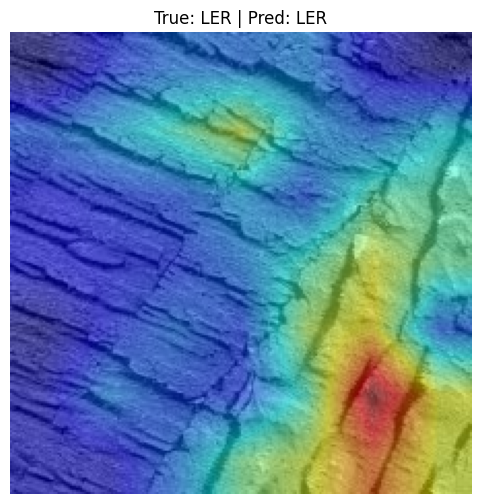

In [8]:
# -----------------------
# Grad-CAM Visualization
# -----------------------

model.eval()
model.load_state_dict(best_model_wts)


# UNFREEZE for Grad-CAM
for param in model.features.parameters():
    param.requires_grad = True
# Choose last convolution layer
target_layer = model.features[-1][0]
print(target_layer)
cam = GradCAM(model=model, target_layers=[target_layer])

# Get one test batch
images, labels = next(iter(test_loader))
images = images.to(device)

# Select first image
input_tensor = images[0].unsqueeze(0)

# Forward pass
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
true_class = labels[0].item()

# Generate CAM for predicted class
targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

# Convert image for visualization
img = images[0].cpu().numpy().transpose(1, 2, 0)
img = (img - img.min()) / (img.max() - img.min())

cam_image = show_cam_on_image(img, grayscale_cam[0], use_rgb=True)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(cam_image)
plt.title(f"True: {test_dataset.classes[true_class]} | Pred: {test_dataset.classes[pred_class]}")
plt.axis('off')
plt.show()

True Label: LER


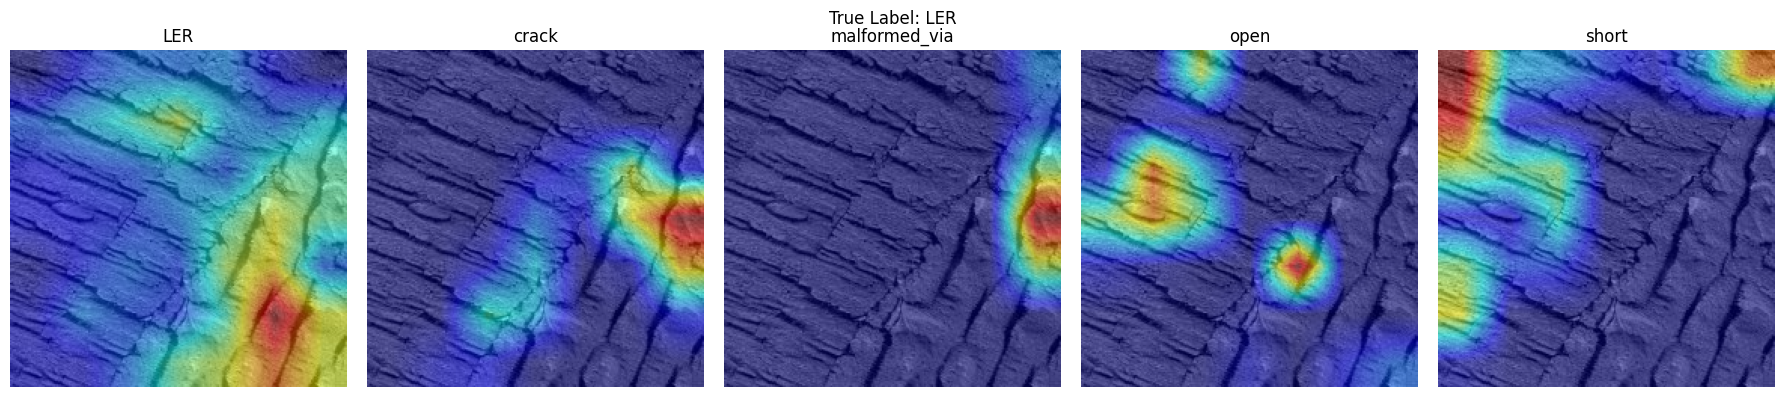

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Best Model
# -----------------------

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# IMPORTANT: Unfreeze backbone for Grad-CAM
for param in model.parameters():
    param.requires_grad = True

# -----------------------
# 2️⃣ Select One Test Image
# -----------------------

images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
true_label = labels[0].item()

print("True Label:", test_dataset.classes[true_label])

# -----------------------
# 3️⃣ Define Target Layer
# (For MobileNetV3 Small)
# -----------------------

target_layers = [model.features[-1][0]]

# -----------------------
# 4️⃣ Create GradCAM Object
# -----------------------

cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------
# 5️⃣ Prepare Image for Display
# -----------------------

rgb_img = images[0].permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# -----------------------
# 6️⃣ Generate Grad-CAM for ALL Classes
# -----------------------

num_classes = len(test_dataset.classes)

plt.figure(figsize=(18, 4))

for class_idx in range(num_classes):

    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=image, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.subplot(1, num_classes, class_idx + 1)
    plt.imshow(visualization)
    plt.title(test_dataset.classes[class_idx])
    plt.axis("off")

plt.suptitle(f"True Label: {test_dataset.classes[true_label]}")
plt.tight_layout()
plt.show()

In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Classification Report:
               precision    recall  f1-score   support

          LER       0.80      0.67      0.73        12
        crack       0.67      1.00      0.80        12
malformed_via       0.82      0.82      0.82        11
         open       0.77      0.83      0.80        24
        short       0.92      0.63      0.75        19

     accuracy                           0.78        78
    macro avg       0.80      0.79      0.78        78
 weighted avg       0.80      0.78      0.78        78


Confusion Matrix:
[[ 8  3  0  1  0]
 [ 0 12  0  0  0]
 [ 0  2  9  0  0]
 [ 1  0  2 20  1]
 [ 1  1  0  5 12]]


In [11]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Model
# -----------------------

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# IMPORTANT: Enable gradients for Grad-CAM
for param in model.parameters():
    param.requires_grad = True

# -----------------------
# 2️⃣ Setup Grad-CAM
# -----------------------

target_layers = [model.features[-1][0]]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------
# 3️⃣ Create Output Folder
# -----------------------

output_root = "gradcam_outputs"
os.makedirs(output_root, exist_ok=True)

# -----------------------
# 4️⃣ Process Entire Test Dataset
# -----------------------

for idx in range(len(test_dataset)):

    img, label = test_dataset[idx]
    true_class = test_dataset.classes[label]

    # Create folder for true label
    class_folder = os.path.join(output_root, true_class)
    os.makedirs(class_folder, exist_ok=True)

    input_tensor = img.unsqueeze(0).to(device)

    # Get prediction
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    pred_class_name = test_dataset.classes[pred_class]

    # Prepare image for visualization
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    num_classes = len(test_dataset.classes)

    plt.figure(figsize=(18, 4))

    for class_idx in range(num_classes):

        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        plt.subplot(1, num_classes, class_idx + 1)
        plt.imshow(visualization)
        plt.title(test_dataset.classes[class_idx])
        plt.axis("off")

    plt.suptitle(f"True: {true_class} | Pred: {pred_class_name}")
    plt.tight_layout()

    # Save figure
    save_path = os.path.join(class_folder, f"img_{idx}.png")
    plt.savefig(save_path)
    plt.close()

print("Grad-CAM generation completed for all test images.")

Grad-CAM generation completed for all test images.


In [12]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Model
# -----------------------

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# Enable gradients (IMPORTANT for Grad-CAM)
for param in model.parameters():
    param.requires_grad = True

# -----------------------
# 2️⃣ Setup Grad-CAM
# -----------------------

target_layers = [model.features[-1][0]]  # MobileNetV3
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------
# 3️⃣ Output Root
# -----------------------

output_root = "structured_gradcam"
os.makedirs(output_root, exist_ok=True)

class_names = test_dataset.classes
num_classes = len(class_names)

# -----------------------
# 4️⃣ Loop Over Entire Test Dataset
# -----------------------

for idx in range(len(test_dataset)):

    img, label = test_dataset[idx]
    true_class = class_names[label]

    # Create folder for TRUE class
    true_class_folder = os.path.join(output_root, f"True_{true_class}")
    os.makedirs(true_class_folder, exist_ok=True)

    # Create subfolder per image
    image_folder = os.path.join(true_class_folder, f"image_{idx}")
    os.makedirs(image_folder, exist_ok=True)

    input_tensor = img.unsqueeze(0).to(device)

    # Prepare image for overlay
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    # -----------------------
    # 5️⃣ Generate CAM for ALL classes
    # -----------------------

    for class_idx in range(num_classes):

        target_class_name = class_names[class_idx]

        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        save_path = os.path.join(
            image_folder,
            f"cam_{target_class_name}.png"
        )

        plt.imsave(save_path, visualization)

print("Structured Grad-CAM generation completed.")

Structured Grad-CAM generation completed.


In [13]:
import shutil

shutil.make_archive(
    base_name="/kaggle/working/structured_gradcam_results",
    format="zip",
    root_dir="/kaggle/working/structured_gradcam"
)

print("Zip file created successfully!")

Zip file created successfully!


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = test_dataset.classes

In [15]:
accuracy = np.mean(all_preds == all_labels)
print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.782051282051282


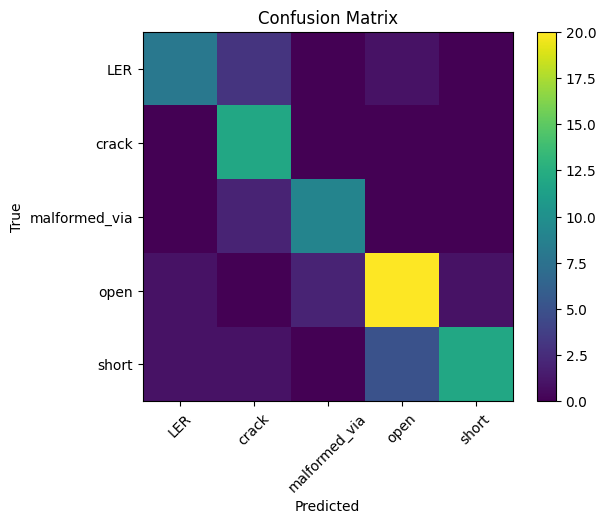

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

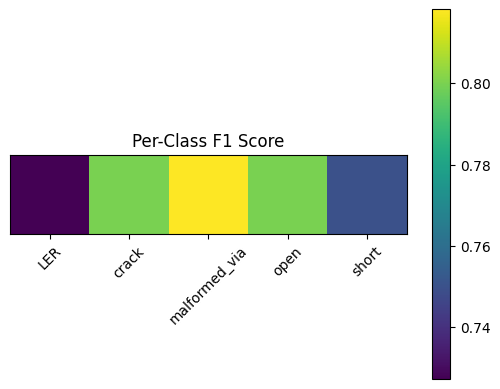

In [17]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

f1_scores = [report[c]["f1-score"] for c in class_names]

plt.figure()
plt.imshow(np.array(f1_scores).reshape(1, -1))
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks([])
plt.title("Per-Class F1 Score")
plt.colorbar()
plt.show()